In [6]:
%ls ../data

inf_2d_dep_lemniscate_pulse_20ions.npz
inf_2d_dep_lemniscate_sym_20_ions_full_ham_eta_0-03.npz
inf_amplitude_dep_rect_pulse_20_ions_eta_0-03.npz
inf_amplitude_dep_rect_pulse_20_ions_full_ham_eta_0-03.npz
inf_amplitude_dep_rect_sym_pulse_20_ions_eta_0-03.npz
inf_amplitude_dep_rect_sym_pulse_20_ions_full_ham_eta_0-03.npz
phase_res_amplitude_dep_rect_pulse_20_ions_full_ham_eta_0-03.npz
phase_res_amplitude_dep_rect_sym_pulse_20_ions_full_ham_eta_0-03.npz


In [2]:
rect_filename     = '../data/inf_amplitude_dep_rect_pulse_20_ions_full_ham_eta_0-03.npz'
rect_sym_filename = '../data/inf_amplitude_dep_rect_sym_pulse_20_ions_full_ham_eta_0-03.npz'

In [3]:
def plot_fidelity_dep(filename, title, xlim=None, ylim=None):
    datafile = np.load(filename)
    rel_f_range = datafile['rel_f_range']
    inf_arr = datafile['inf_arr']
    n_loops_arr = datafile['n_loops_arr']
    for n_loops, inf_range in zip(n_loops_arr, inf_arr):
        plt.plot(rel_f_range, inf_range, label=f'$n_{{loops}} = {n_loops}$')
    plt.yscale('log')
    plt.margins(x=0)
    plt.title(title)
    plt.xlabel('$2f/\sqrt{n_{loops}}$')
    plt.ylabel('$1-F$')
    plt.legend()
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid()

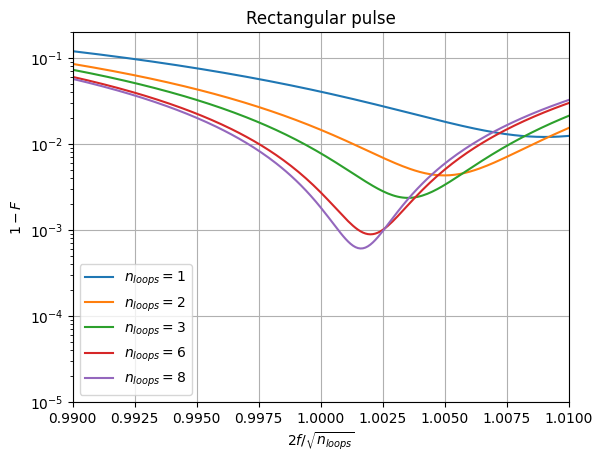

In [4]:
plot_fidelity_dep(rect_filename, title='Rectangular pulse', ylim=(1e-5, 2e-1))

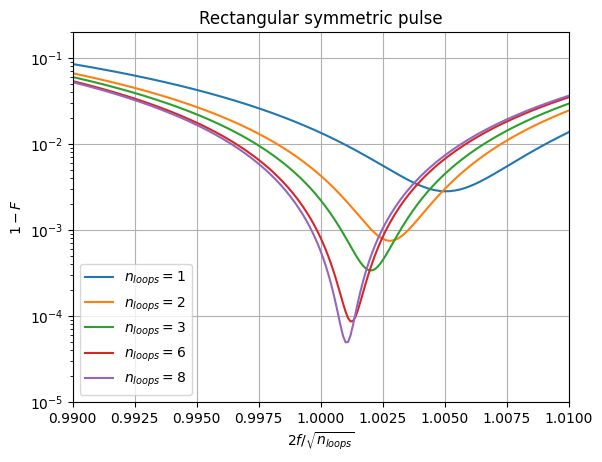

In [5]:
plot_fidelity_dep(rect_sym_filename, title='Rectangular symmetric pulse', ylim=(1e-5, 2e-1))

In [91]:
datafile = np.load('../data/phase_res_amplitude_dep_rect_pulse_20_ions_full_ham_eta_0-03.npz')
datafile = np.load('../data/phase_res_amplitude_dep_rect_sym_pulse_20_ions_full_ham_eta_0-03.npz')

In [92]:
set(datafile.keys())

{'n_loops_arr', 'phase_res_arr', 'rel_f_range'}

In [93]:
rel_f_range = datafile['rel_f_range']
n_loops_arr = datafile['n_loops_arr']
phase_res_arr = datafile['phase_res_arr']

In [99]:
n_loops = 6
k = list(n_loops_arr).index(n_loops)
phase_res = phase_res_arr[k]

In [100]:
from tdse_solutions import *

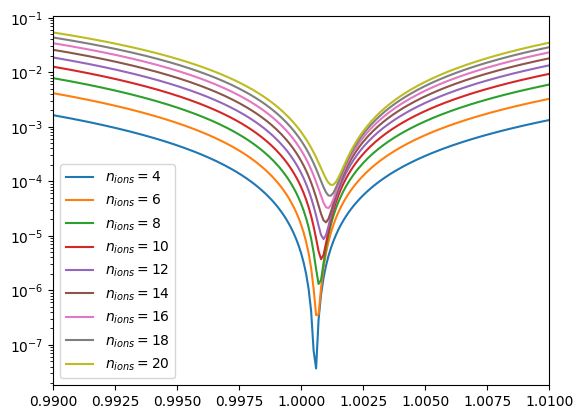

In [101]:
n_ions_max = 20
for n_ions in range(4, 21, 2):  
    delta_n = int((n_ions_max - n_ions)/2)
    if delta_n == 0:
        phase_res_part = phase_res
    else:
        phase_res_part = phase_res[:,delta_n:-delta_n]
    
    inf_range = []
    
    for rel_f, pr in zip(rel_f_range, phase_res_part):
        inf = 1 - fidelity_from_phase_residuals(pr)
        inf_range.append(inf)
    plt.plot(rel_f_range, inf_range, label=rf'$n_{{ions}}={n_ions}$')
plt.yscale('log')
plt.legend()
plt.margins(x=0)